In [7]:
import os
import numpy as np
import seaborn as sns

from torchvision.transforms import v2
import torchvision
import torchvision.datasets as ds_loader
from torch.utils.data import DataLoader, Dataset

from pathlib import Path
import sys

In [3]:

LCL_PATH  = str(Path().cwd())
ROOT_PATH = str(Path(LCL_PATH).parent)
DEEPL_PATH = str(Path(ROOT_PATH)/"deep_learning")
print("""
root path:\t{}
local path:\t{}
deep learning path:\t{}""".format(ROOT_PATH, LCL_PATH, DEEPL_PATH))


root path:	/home/gheorghe/Desktop/Proiecte/master/CARN
local path:	/home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation
deep learning path:	/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning


In [4]:

# adding local_folder to the system path
sys.path.append(ROOT_PATH)
sys.path.append(LCL_PATH)
sys.path.append(DEEPL_PATH)

from sys_function import * # este in root

In [5]:

sys_remove_modules("dataset.dataset_rand_append")
sys_remove_modules("checks.tensor_check")

from dataset.dataset_rand_append import *
from checks.tensor_check import *

## Data aquisition

### Manipulation/preprocesing

#### Check function

In [7]:

def check_transforms(transform, inputs, shape, max_val, min_val, dtype):
    # check 1000 tests
    for _ in range(1000):
        x = transform(inputs)
        tensor_check(x, shape, max_val, min_val, dtype)
    else:
        print("OK")

In [8]:

def check_all_transforms(transform, inputs, outputs, in_shape, out_shape, max_val, min_val, dtype):
    for _ in range(1000):
        x, y = transform(inputs, outputs)
        tensor_check(x, in_shape, max_val, min_val, dtype)
        tensor_check(y, out_shape, 1.5, -1.3, dtype)
    else:
        print("OK")

#### Init transform

In [9]:

def get_init_transform(train, image_size):
    transform = [ # image->tensor->resize->make square-> 
            # if use 'ToImage' tensor should be numpy array!!!
            v2.ToImage(), # data are transorm to torch tensor in Dataset manager, tensor should be numpy array!!!
            v2.Resize(
                size=int(image_size),),
            v2.CenterCrop(image_size),
        ]
    if (train == False):
        transform.extend([
                v2.ToDtype(torch.float32, scale=False), # scale True normalized
                v2.Normalize(
                    #mean=(0.5, 0.5, 0.5), 
                    #std=(0.5, 0.5, 0.5), 
                    #mean=(0.491, 0.482, 0.446), 
                    #std=(0.247, 0.243, 0.261), 
                    mean=(125.205, 122.91, 113.73), 
                    std=(62.985, 61.965, 66.555), 
                    inplace=True),
            ])
                # We use the inplace flag because we can safely change the tensors inplace when normalize is used.
                # For is_train=False, we can safely change the tensors inplace because we do it only once, when caching.
                # For is_train=True, we can safely change the tensors inplace because we clone the cached tensors first.
    return v2.Compose(transform)

In [11]:

transform = get_init_transform(False, IMAGE_SIZE)
inputs = np.ones((32, 32, 3), dtype=np.uint8) * 255
shape = (3, IMAGE_SIZE, IMAGE_SIZE)
check_transforms(transform, inputs, shape, 2.4, -2.4, torch.float32)

OK


In [12]:

transform = get_init_transform(True, IMAGE_SIZE)
inputs = np.ones((32, 32, 3), dtype=np.uint8) * 255
shape = (3, IMAGE_SIZE, IMAGE_SIZE)
check_transforms(transform, inputs, shape, 255, 0, torch.uint8)

OK


#### Transform

In [13]:

def get_transforms(image_size: int):
    # These transformations are cached.
    # We could have used RandomCrop with padding. But we are smart, and we know we cache the initial_transforms so
    # we don't compute them during runtime. Therefore, we do the padding beforehand, and apply cropping only at
    # runtime
    random_choice = v2.RandomChoice([
        v2.RandomPerspective(
                    distortion_scale=0.15, # controls how much each corner can move. 
                    p=1.0),                # probability of applying the effect
        v2.RandomRotation(degrees=30),     # rotates an image with random angle
        v2.RandomAffine(
                    degrees=30,             # rotation ±30
                    translate=(0.15, 0.15), # horizontal/vertical translation as fraction of image
                    scale=(0.75, 1.05),     # scale factor
                    shear=10),              # shear angle ±10°
        v2.RandomCrop(
                    size=image_size,   # height & width of crop
                    padding=4),        # pixels to pad around the image
        v2.RandomResizedCrop(
                    size=image_size,
                    scale=(0.75, 1.),  # range of area proportion to crop from the original image
                    ratio=(0.8,  1.)), # range of aspect ratio (width/height)
        v2.RandomAdjustSharpness(
                    sharpness_factor=1.5, # controls the degree of sharpness; ( >1 sharpened; <1 slightly blurred)
                    p=1.),                      # probability of applying the transform
        v2.RandomAutocontrast(p=1.), # probability of applying the transform
        v2.RandomEqualize( # histogram of pixel values
                    p=1.), # probability of applying the transform
        v2.ColorJitter(  # randomly changes the brightness, contrast, saturation, and hue
                    brightness=0.5, # factor to change brightness
                    contrast=0.3,   # factor to change contrast
                    saturation=0.3, # factor to change saturation
                    hue=0.3,),      # factor to change hue
        v2.GaussianBlur(  # applies a Gaussian blur
                    kernel_size=(7, 7), # size of the Gaussian kernel
                    # standard deviation of the Gaussian kernel; a float or tuple (min, max) for random sampling
                    sigma=(0.1, 5.)),   # how to handle image borders
        v2.RandomErasing(
                    scale=(0.01, 0.15), # range of area ratio to erase (relative to image area)
                    value=10,           # fill value: single number, tuple, or 'random'
                    inplace=False,      # whether to erase in place or return a new image
                    p=1.),              # probability of applying the transform
        v2.Grayscale(num_output_channels=3), # number of channels in output image: 1 or 3
        v2.RandomHorizontalFlip(),
        v2.Identity(),  # returns the input image unchanged
    ])
    transforms = v2.Compose([random_choice,
        v2.ToDtype(torch.float32, scale=False), # converts uint8 [0,255] -> float32 [0,1]
        v2.Normalize(
                #mean=(0.5, 0.5, 0.5), 
                #std=(0.5, 0.5, 0.5), 
                #mean=(0.491, 0.482, 0.446), 
                #std=(0.247, 0.243, 0.261), 
                mean=(125.205, 122.91, 113.73), 
                std=(62.985, 61.965, 66.555), 
                inplace=True),
        ])
    # We use the inplace flag because we can safely change the tensors inplace when normalize is used.
    # For is_train=False, we can safely change the tensors inplace because we do it only once, when caching.
    # For is_train=True, we can safely change the tensors inplace because we clone the cached tensors first.

    # Q: How to make this faster?
    # A: Use batched runtime transformations. y
    return transforms

In [14]:

transform = get_transforms(IMAGE_SIZE)
inputs = torch.ones((3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.uint8) * 255
shape = (3, IMAGE_SIZE, IMAGE_SIZE)
check_transforms(transform, inputs, shape, 2.4, -2.4, torch.float32)

OK


#### All transform

In [15]:

def get_all_transforms(num_classes: int = 10):
    transforms = v2.RandomChoice([
                v2.CutMix(num_classes=num_classes),  # See the CutMix paper
                v2.MixUp(num_classes=num_classes),   # See the MixUp paper
                LabelSmoothing(num_classes=num_classes, smooth_size=0.13),  # 
            ])
    return transforms

In [ ]:

transform = get_all_transforms(num_classes=NUM_CLASSES)
inputs  = torch.ones((BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.float32)
outputs = torch.zeros((BATCH_SIZE,), dtype=torch.int64)
print(transform)
in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = (BATCH_SIZE, NUM_CLASSES)
check_all_transforms(transform, inputs, outputs, in_shape, out_shape, 3, -3, torch.float32)

In [ ]:

tmp_l = LabelSmoothing(num_classes=10, smooth_size=0.13)
y = torch.zeros((BATCH_SIZE,), dtype=torch.int64)
for _ in range(1000):
    tmp0, tmp1 = tmp_l(None, y)
    if (torch.less(tmp1, 0).sum() > 0):
        print(torch.less(tmp1, 0).sum())

### Aquisition

In [16]:

cifar10_train = CIFAR10(root="./data", train=True, transform=None, download=True)
print(str(cifar10_train))
cifar10_test = CIFAR10(root="./data", train=False, transform=None, download=True)
print(str(cifar10_test))

Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test


In [8]:

oxfordIIIPet_train = ds_loader.OxfordIIITPet(root="./data", split="trainval", 
                             target_types="category", 
                             transform=None, download=True)
oxfordIIIPet_test  = ds_loader.OxfordIIITPet(root="./data", split="test", 
                             target_types="category", 
                             transform=None, download=True)

100%|████████████████████████| 791918971/791918971 [05:50<00:00, 2256286.53it/s]


Extracting data/oxford-iiit-pet/images.tar.gz to data/oxford-iiit-pet


100%|██████████████████████████| 19173078/19173078 [00:07<00:00, 2709788.75it/s]


Extracting data/oxford-iiit-pet/annotations.tar.gz to data/oxford-iiit-pet


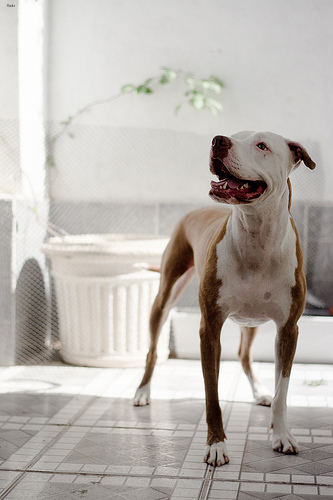

In [46]:

input, target = oxfordIIIPet_train[100]
input

In [36]:

ds_train = ds_loader.Caltech256(root="./data", 
                             transform=None, download=True)

Using downloaded and verified file: ./data/caltech256/256_ObjectCategories.tar
Extracting ./data/caltech256/256_ObjectCategories.tar to ./data/caltech256


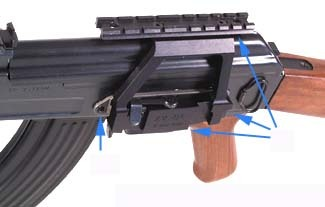

In [40]:
input, target = ds_train[5]
input

In [41]:

mnist_train_ds = ds_loader.MNIST(root='./data', train=True,  transform=None, download=True)
mnist_test_ds  = ds_loader.MNIST(root='./data', train=False, transform=None, download=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████| 9912422/9912422 [00:18<00:00, 522133.80it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████| 28881/28881 [00:00<00:00, 113241.51it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████| 1648877/1648877 [00:03<00:00, 479632.69it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████| 4542/4542 [00:00<00:00, 20707096.49it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [43]:
input, target = mnist_test_ds[0]
input